# Project - 3 Graph Neural Network Model


In [1]:
!python --version

Python 3.12.13


In [2]:
!python -c "import torch; print(torch.version.cuda)"

12.1


In [3]:
!python -c "import torch; print(torch.__version__)"

2.3.0+cu121


In [4]:
# Installing required packages
# To ensure compatibility with PyTorch Geometric's pre-compiled wheels for CUDA 12.x in Colab,
# it's often necessary to install a specific, known-working PyTorch version.
# We will install PyTorch 2.3.0 with CUDA 12.1 (which works with Colab's CUDA 12.8 drivers).
!pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu121

# Now, install torch-scatter and torch-sparse using the correct PyG wheel links for PyTorch 2.3.0+cu121
# Use --force-reinstall in case partial installations are present.
!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.3.0+cu121.html --force-reinstall

# Finally, install torch-geometric
!pip install torch_geometric

print("\n--- Verification After Installation ---")
import torch
import torch_geometric

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version (detected by PyTorch): {torch.version.cuda}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"torch_geometric version: {torch_geometric.__version__}")

# It's often recommended to restart the runtime after significant library installations/reinstallations.
# Go to 'Runtime' -> 'Restart runtime' if you encounter further issues.

In [5]:
# Importing required libraries
%matplotlib inline
import torch
import networkx as nx

import matplotlib.pyplot as plt
from torch_geometric.datasets import KarateClub

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.0+cu121
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [6]:
# Loading dataset
dataset = KarateClub()


In [7]:
dataset.num_classes

4

In [8]:
# Getting first graph object
data = dataset[0]
print(data)

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])


# Train Mask

A boolean array of the same length as the number of nodes. It holds a True value for nodes meant for training, and False for validation or testing nodes.

In [9]:
data.stores

[{'x': tensor([[1., 0., 0.,  ..., 0., 0., 0.],
         [0., 1., 0.,  ..., 0., 0., 0.],
         [0., 0., 1.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 1., 0., 0.],
         [0., 0., 0.,  ..., 0., 1., 0.],
         [0., 0., 0.,  ..., 0., 0., 1.]]), 'edge_index': tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,
           1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,
           3,  3,  3,  3,  3,  4,  4,  4,  5,  5,  5,  5,  6,  6,  6,  6,  7,  7,
           7,  7,  8,  8,  8,  8,  8,  9,  9, 10, 10, 10, 11, 12, 12, 13, 13, 13,
          13, 13, 14, 14, 15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 19, 20, 20, 21,
          21, 22, 22, 23, 23, 23, 23, 23, 24, 24, 24, 25, 25, 25, 26, 26, 27, 27,
          27, 27, 28, 28, 28, 29, 29, 29, 29, 30, 30, 30, 30, 31, 31, 31, 31, 31,
          31, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 33, 33, 33, 33, 33,
          33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33],
    

In [10]:
data.y

tensor([1, 1, 1, 1, 3, 3, 3, 1, 0, 1, 3, 1, 1, 1, 0, 0, 3, 1, 0, 1, 0, 1, 0, 0,
        2, 2, 0, 0, 2, 0, 0, 2, 0, 0])

In [11]:
data.y.shape

torch.Size([34])

In [12]:
data.train_mask

tensor([ True, False, False, False,  True, False, False, False,  True, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False,  True, False, False, False, False, False,
        False, False, False, False])

Above only 4 nodes have mask value set as True, it means only 4 out of 34 nodes have community or class assignments, rest of the 30 nodes need community assignment. So, we can only use the 4 nodes as training mask and the 30 other nodes cannot be used.

In [13]:
data.train_mask.shape

torch.Size([34])

# Validation & Test Mask

If the graph holds the additional attributes i.e., val_mask and test_mask, which denotes which nodes should be used for validation and testing.

# GNN Objective

We have 4 nodes only with the community assigned so we need to assign remaining 30 nodes.

In short, the final output should be that all 34 nodes should belong to 4 different community.

# Initializing The Model

In [14]:
from torch.nn import Linear
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
  # Initialization function
  def __init__(self):
    super().__init__()
    torch.manual_seed(1234) # This locks the random number generator, it means, at every signgle time when we instatntiate the GCN class it starts with exact same initial weights.
    # 3 layers
    self.conv1 = GCNConv(dataset.num_features, 4)
    self.conv2 = GCNConv(4, 4)
    self.conv3 = GCNConv(4, 2)
    # This standard linear layer takes those 2D coordinates and maps them directly to your target classes i.e., 4, outputting raw probability scores for each class.
    self.classifier = Linear(2, dataset.num_classes)

  # Forward propagation function
  def forward(self, x, edge_index):
    h = self.conv1(x, edge_index)
    h = h.tanh()
    h = self.conv2(h, edge_index)
    h = h.tanh()
    h = self.conv3(h, edge_index)
    h = h.tanh() # Final GNN embedding space.

    # Apply a final (linear) classifier
    out = self.classifier(h)

    return out, h

# Initializing the object
model = GCN()
print(model)


GCN(
  (conv1): GCNConv(34, 4)
  (conv2): GCNConv(4, 4)
  (conv3): GCNConv(4, 2)
  (classifier): Linear(in_features=2, out_features=4, bias=True)
)


In [15]:
model = GCN()

_, h = model(data.x, data.edge_index)
print(f"Embedding space: {list(h.shape)}")
h

Embedding space: [34, 2]


tensor([[ 0.0962,  0.0115],
        [ 0.0235,  0.0129],
        [ 0.0432,  0.0201],
        [ 0.0401,  0.0162],
        [ 0.0522, -0.0054],
        [ 0.0775,  0.0011],
        [ 0.0763,  0.0031],
        [ 0.0300,  0.0131],
        [ 0.0107,  0.0181],
        [ 0.0014,  0.0195],
        [ 0.0575, -0.0035],
        [ 0.0867,  0.0090],
        [ 0.0353,  0.0106],
        [ 0.0242,  0.0179],
        [-0.0114,  0.0138],
        [-0.0109,  0.0173],
        [ 0.0740,  0.0046],
        [ 0.0188,  0.0012],
        [-0.0139,  0.0210],
        [ 0.0068,  0.0108],
        [ 0.0077,  0.0168],
        [ 0.0014,  0.0033],
        [-0.0065,  0.0175],
        [ 0.0657,  0.0242],
        [ 0.1390,  0.0069],
        [ 0.1296,  0.0110],
        [-0.0140,  0.0309],
        [ 0.0852,  0.0189],
        [ 0.0415,  0.0141],
        [ 0.0032,  0.0333],
        [-0.0036,  0.0152],
        [ 0.0995,  0.0135],
        [ 0.0102,  0.0337],
        [ 0.0181,  0.0381]], grad_fn=<TanhBackward0>)

In [22]:
# Embedding visualing function
def visualize_embedding(h, color, epoch=None, loss=None):
  plt.figure(figsize=(12, 8))
  plt.xticks([])
  plt.yticks([])
  h = h.detach().cpu().numpy() # Converting tensor to numpy array format
  plt.scatter(h[:, 0], h[:, 1], s=140, c=color, cmap="Set2") # 's' is the size of the nodes.
  if epoch is not None and loss is not None:
    plt.xlabel(f"Epoch: {epoch}, Loss: {loss.item():.4f}", fontsize=16)
  plt.show()

In [30]:
# Embedding visualization function in 2D plane
from sklearn.manifold import TSNE # (t-Distributed Stochastic Neighbor Embedding), used for dimensionality reduction and data visualization. Mathematically compresses the higher dimensional data down into a 2D or 3D map while keeping similar data points close to each other.

def visualize_tsne(h, color):
  z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

  plt.figure(figsize=(10, 10))
  plt.xticks([])
  plt.yticks([])

  plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
  plt.show()

In [18]:
data.y

tensor([1, 1, 1, 1, 3, 3, 3, 1, 0, 1, 3, 1, 1, 1, 0, 0, 3, 1, 0, 1, 0, 1, 0, 0,
        2, 2, 0, 0, 2, 0, 0, 2, 0, 0])

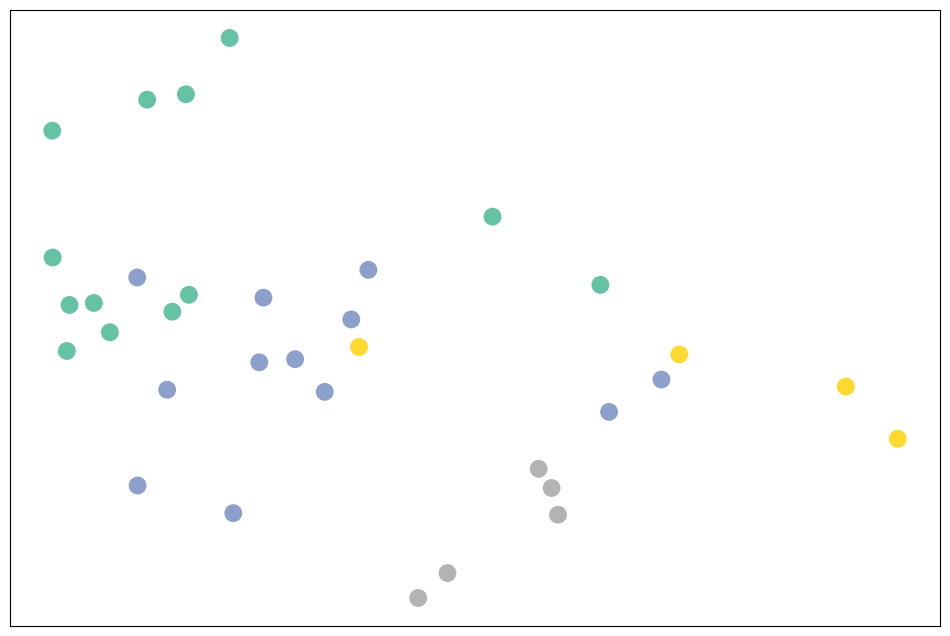

In [19]:
# Visualizing embedding
visualize_embedding(h, color=data.y)

# Training Method

<IPython.core.display.Javascript object>

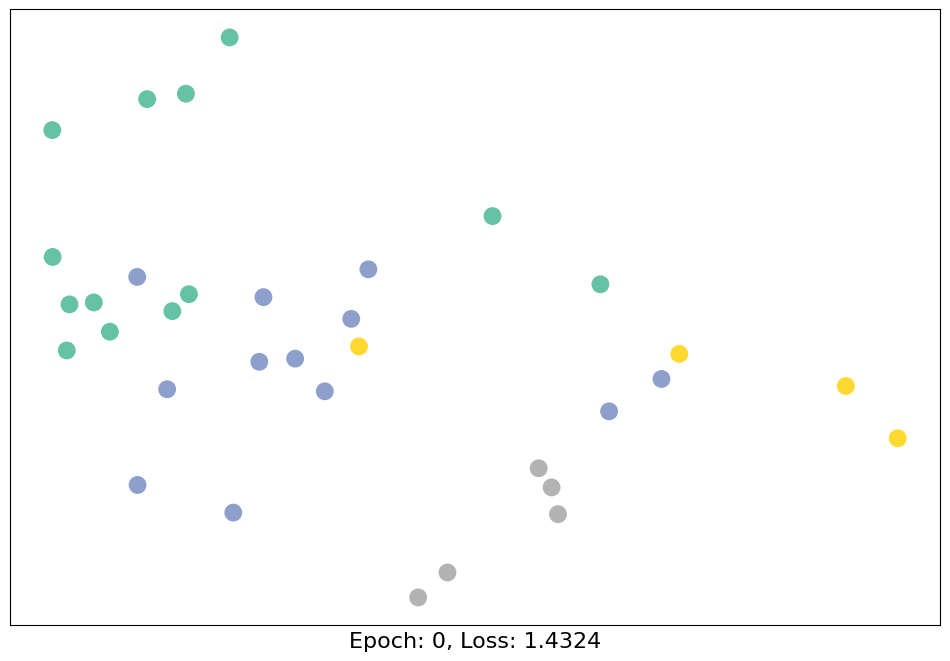

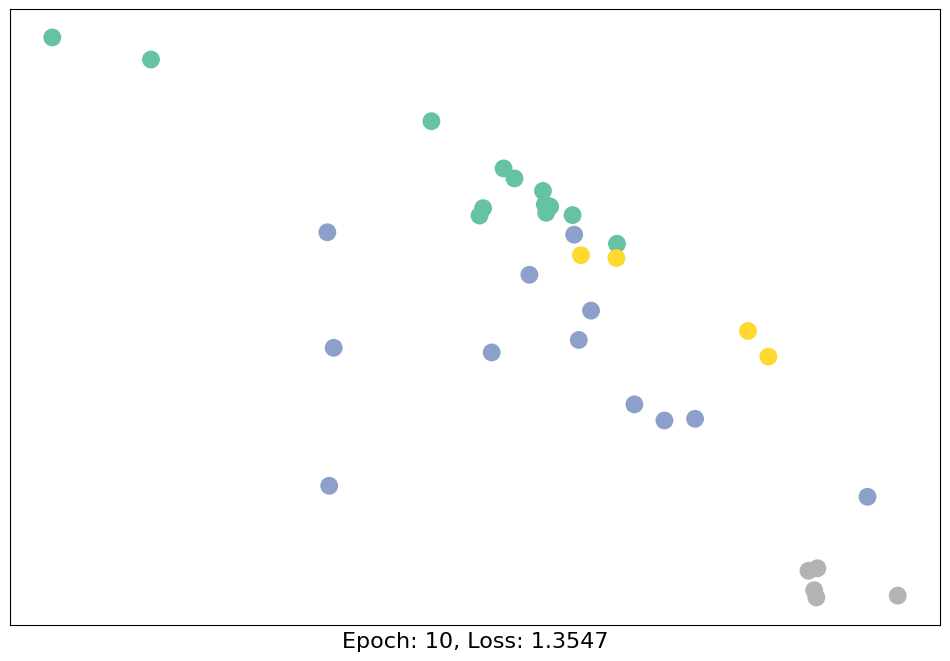

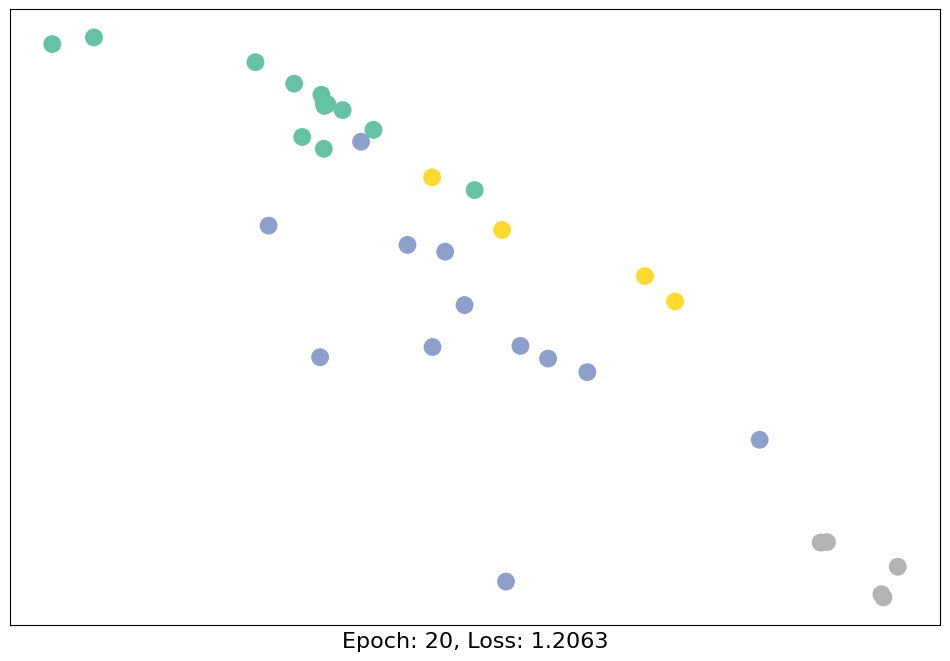

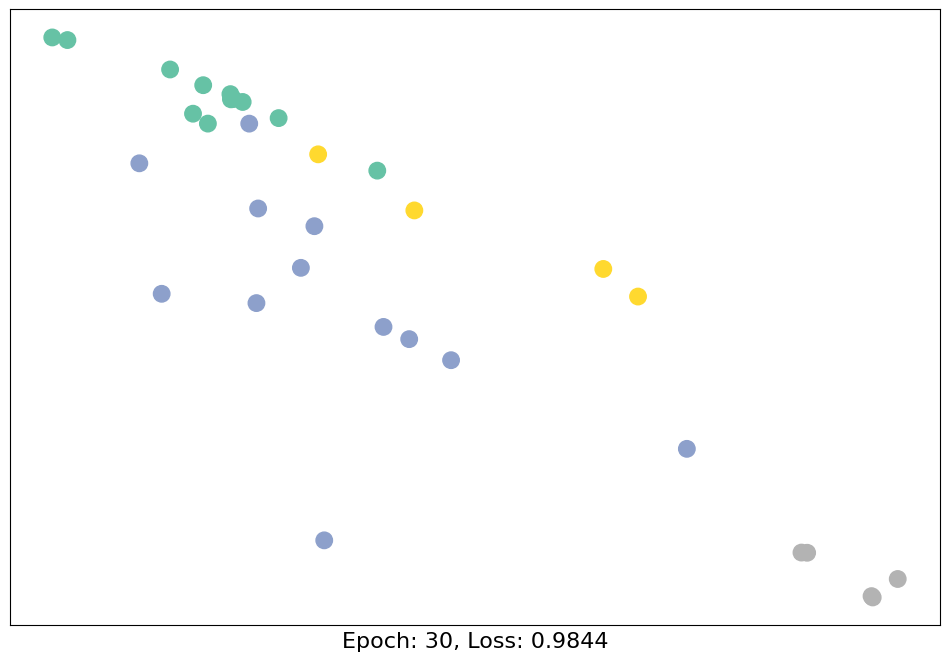

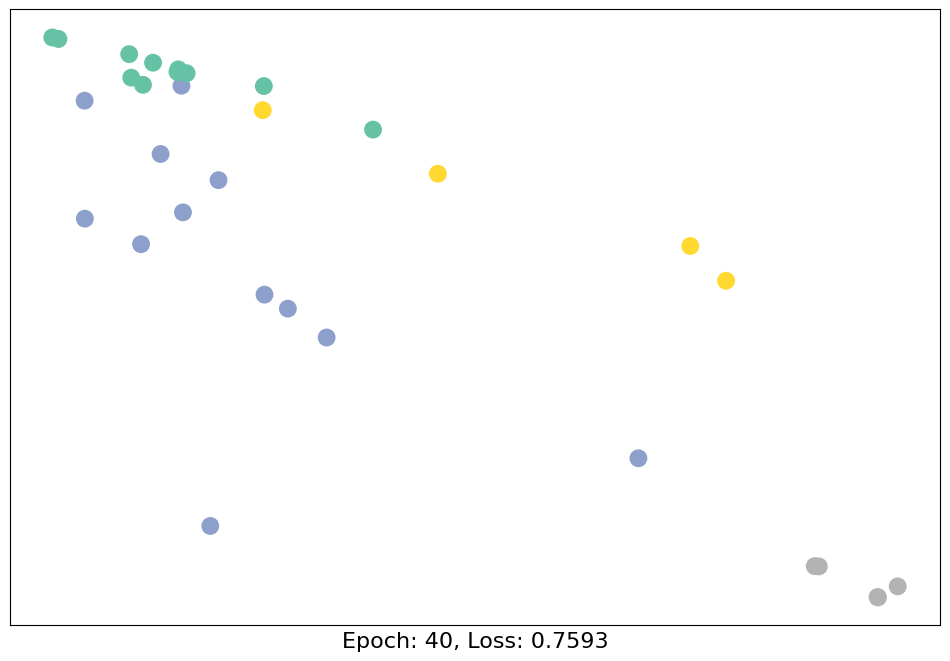

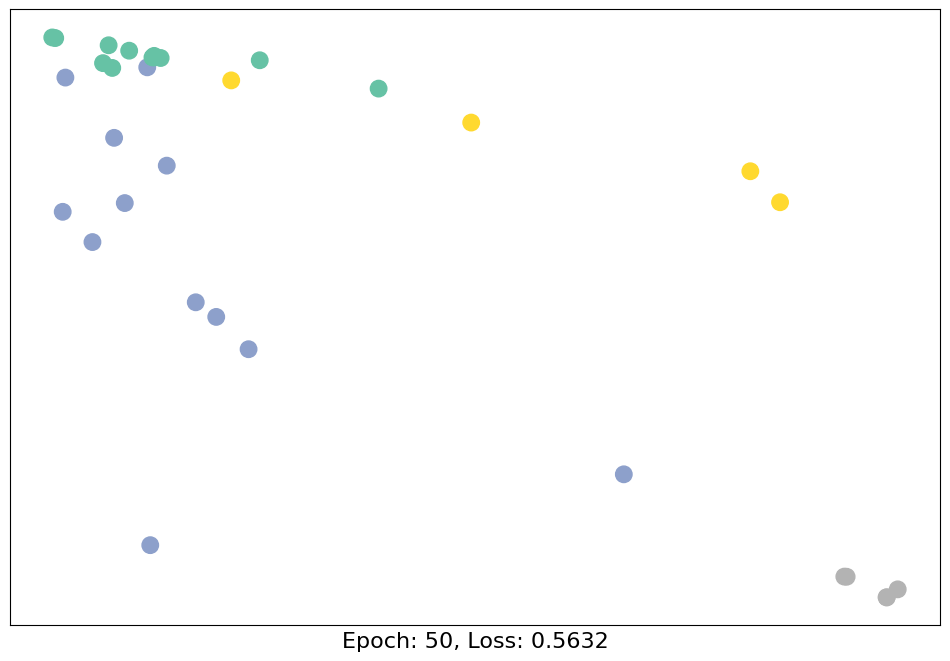

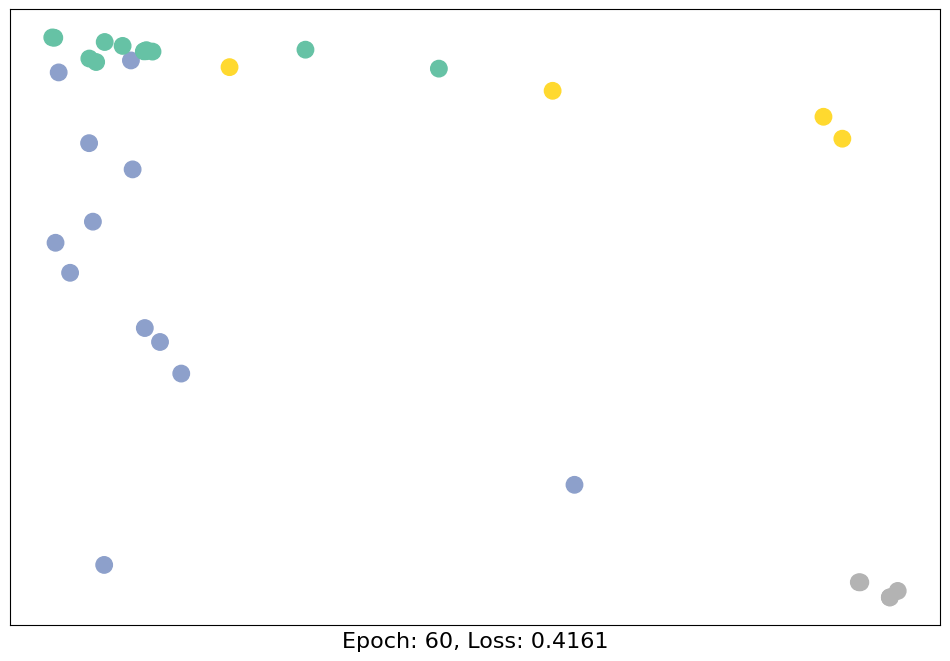

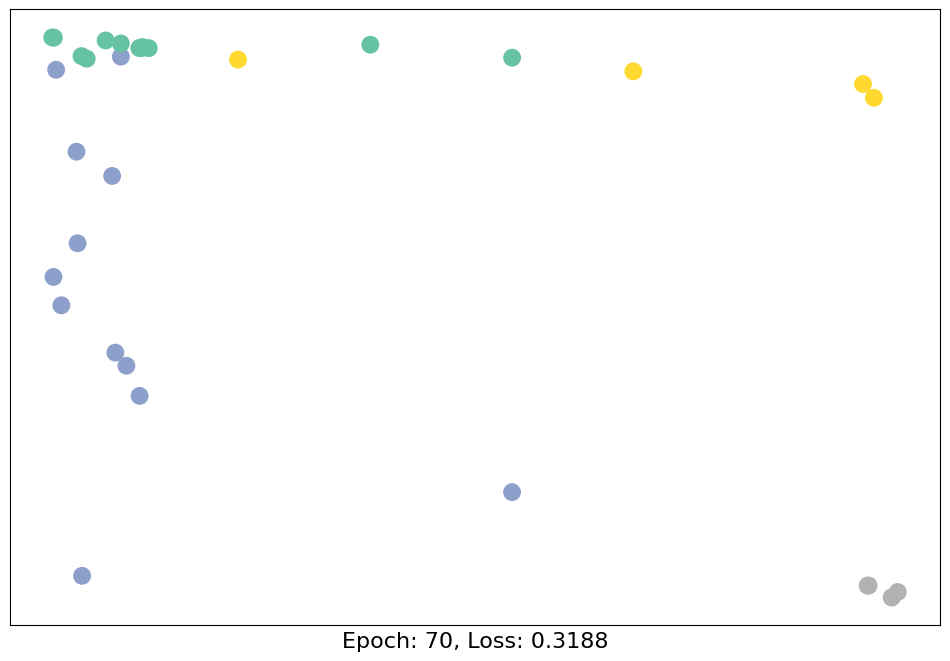

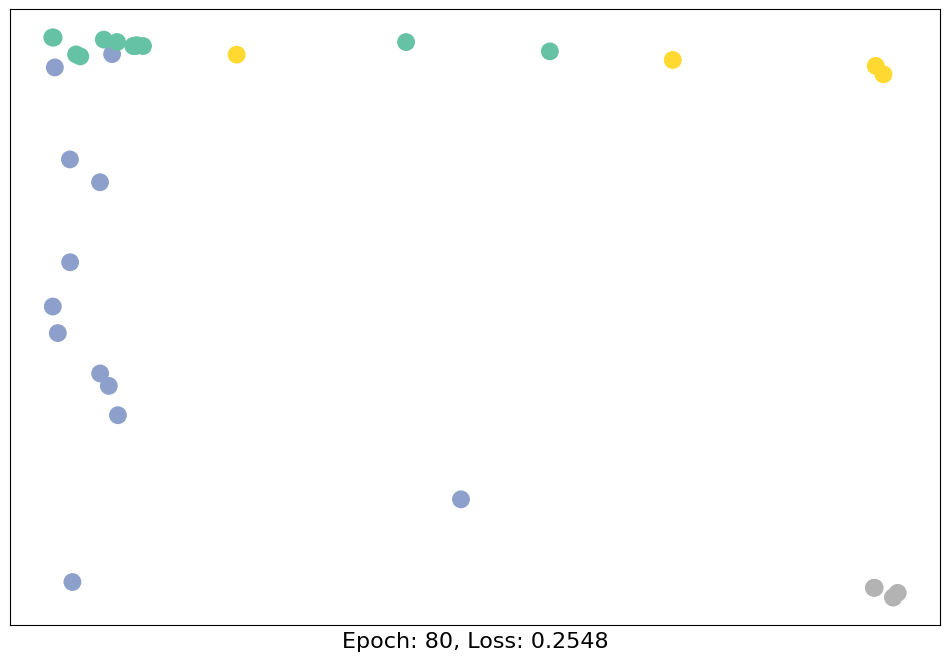

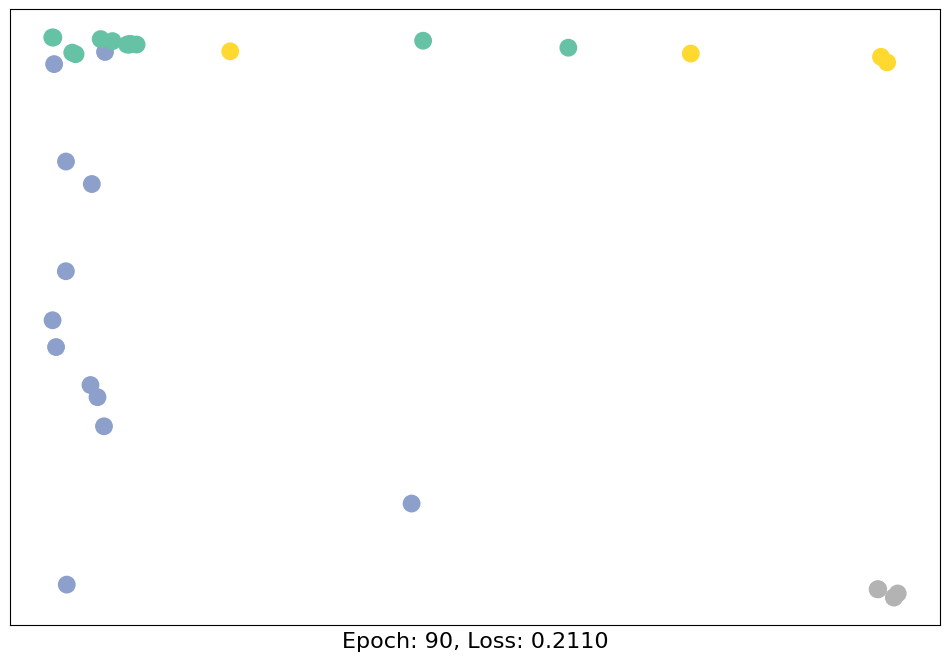

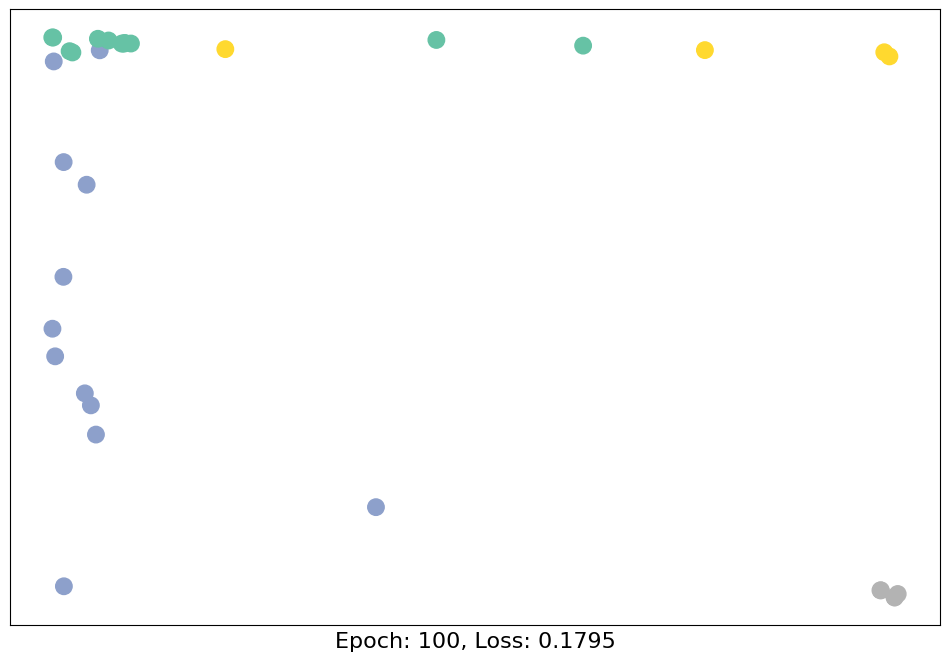

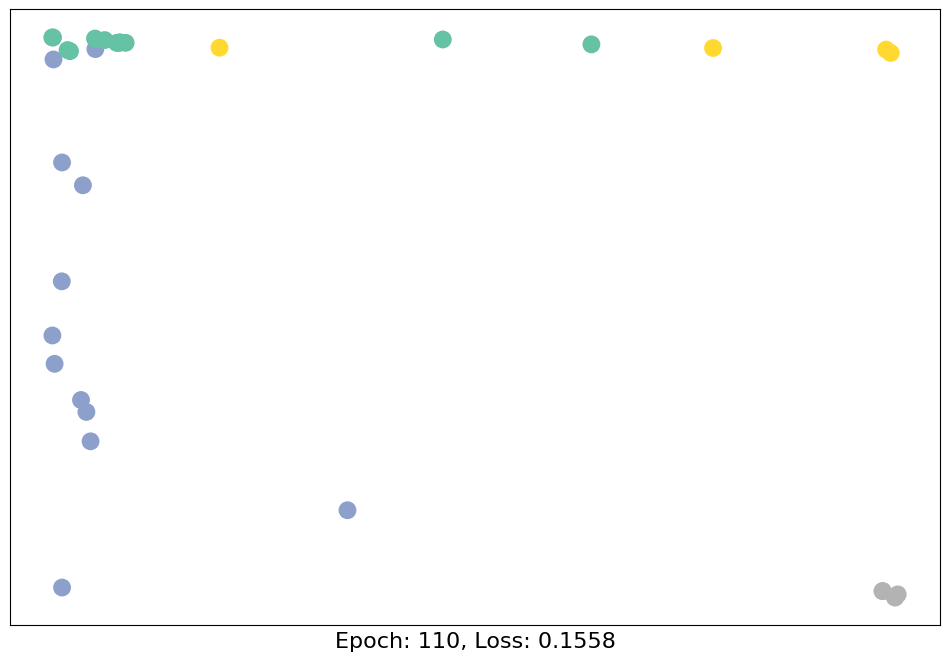

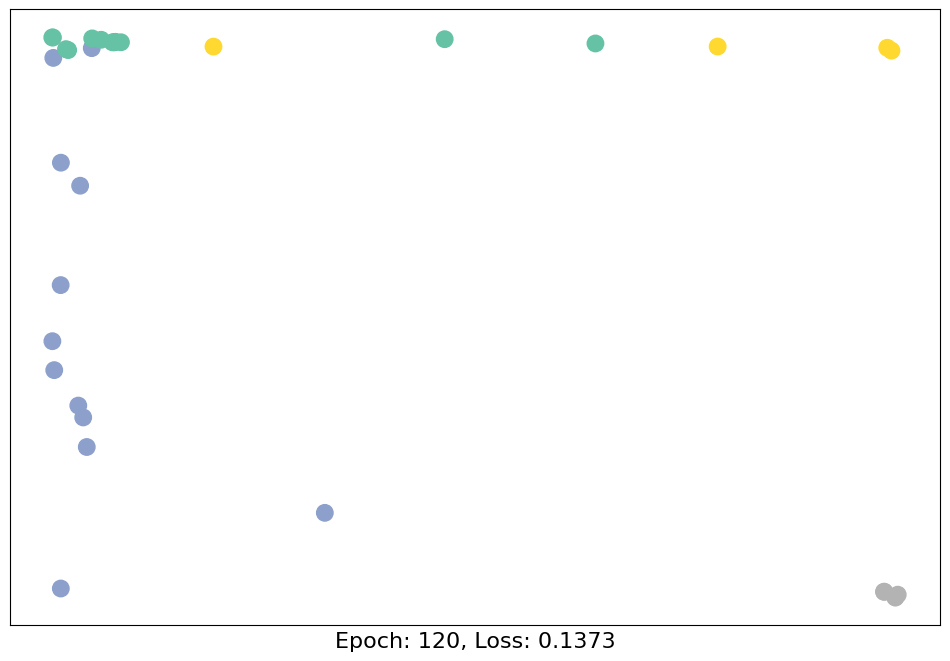

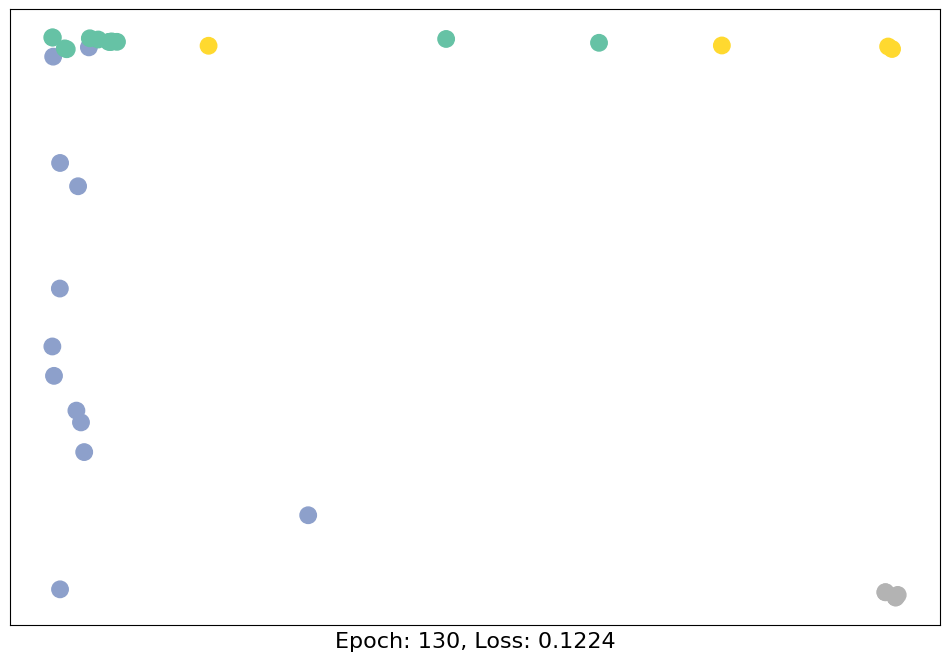

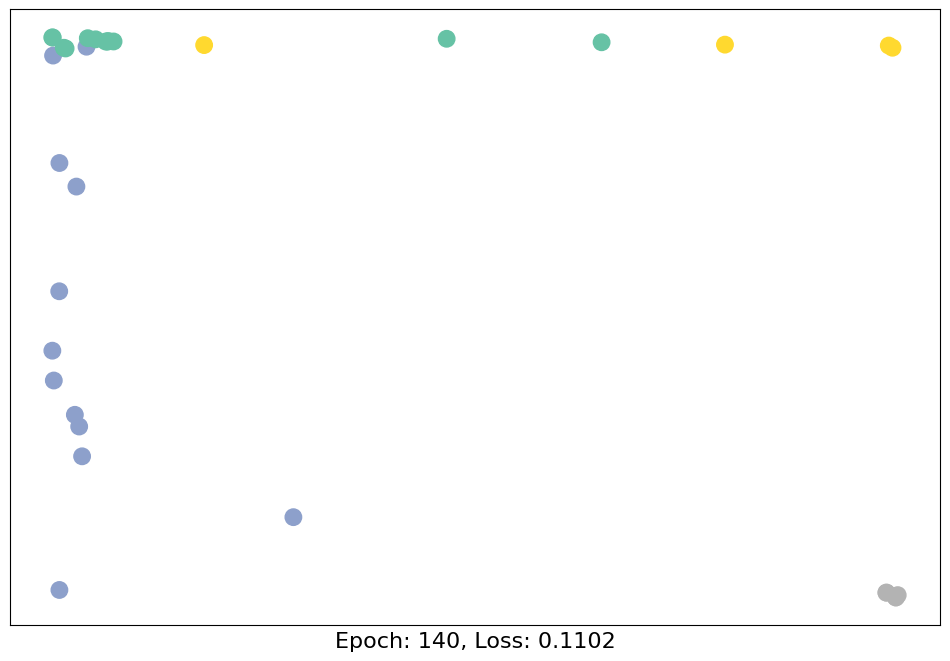

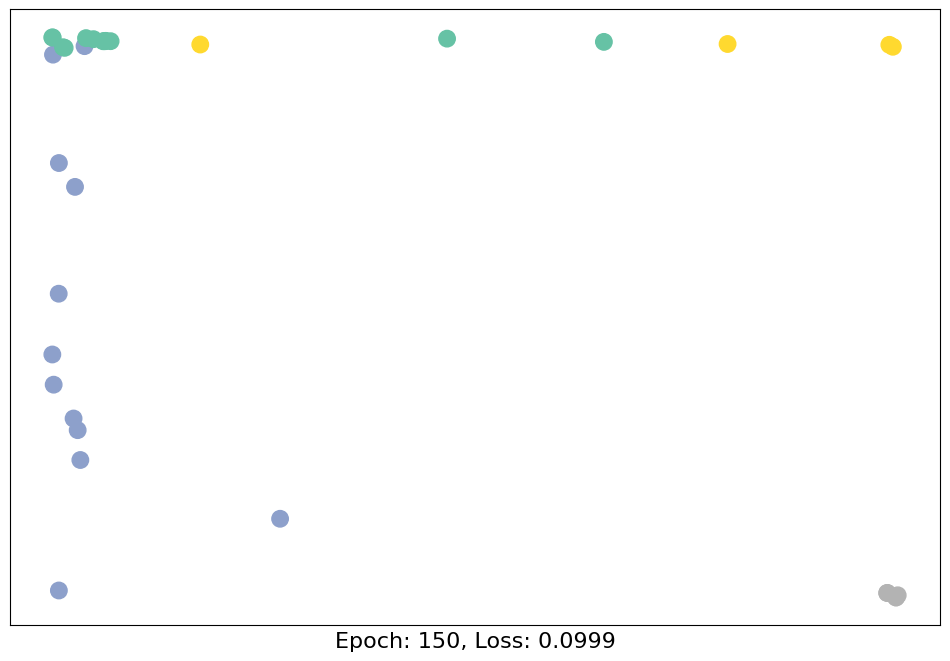

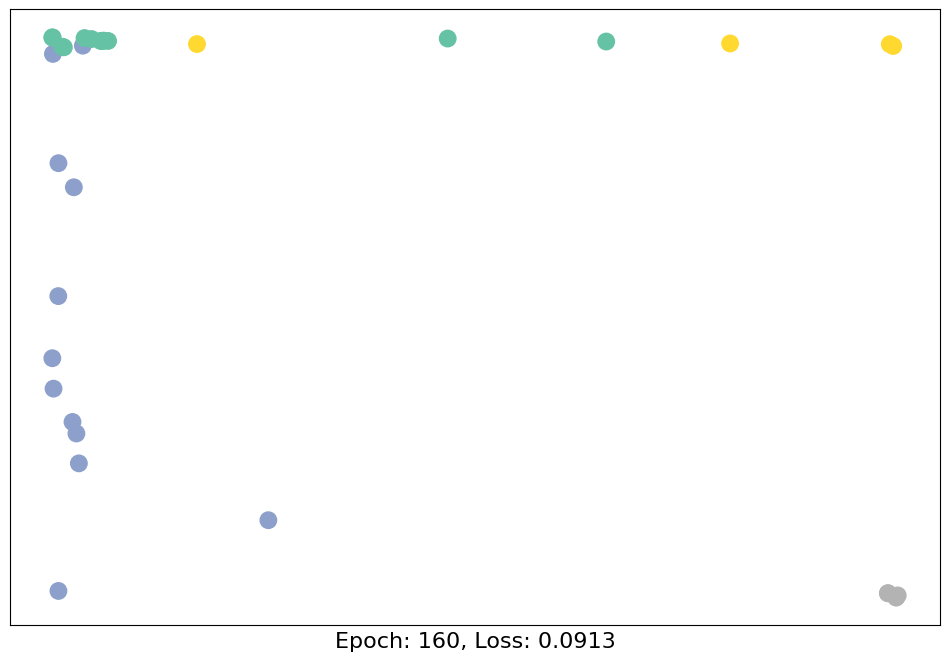

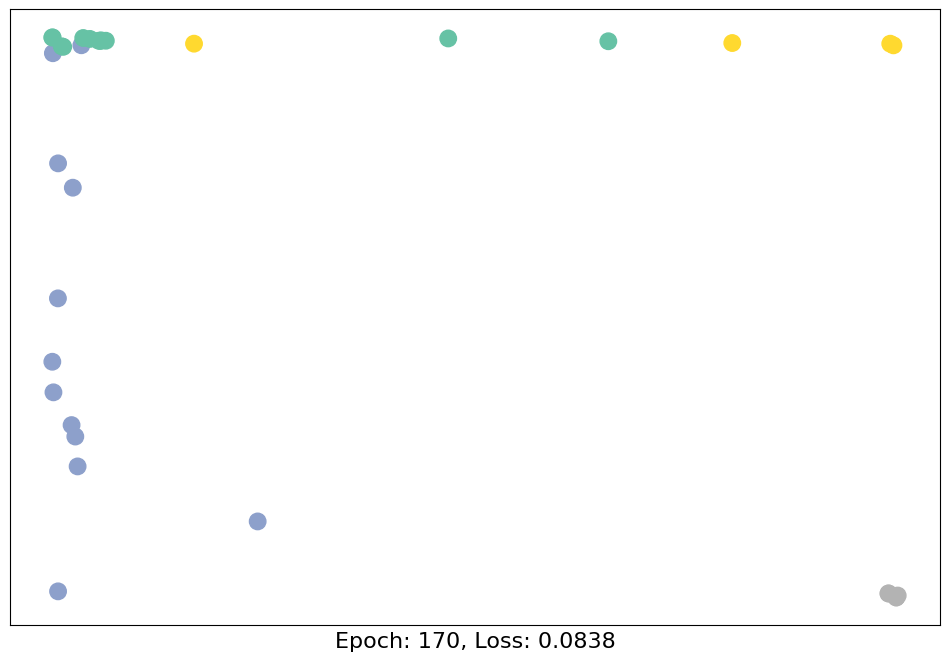

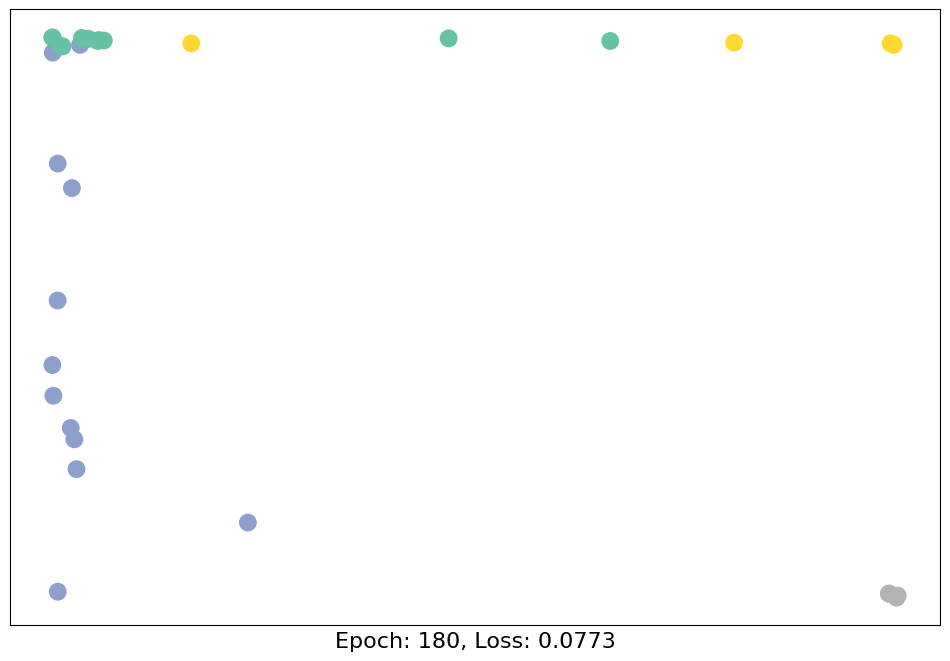

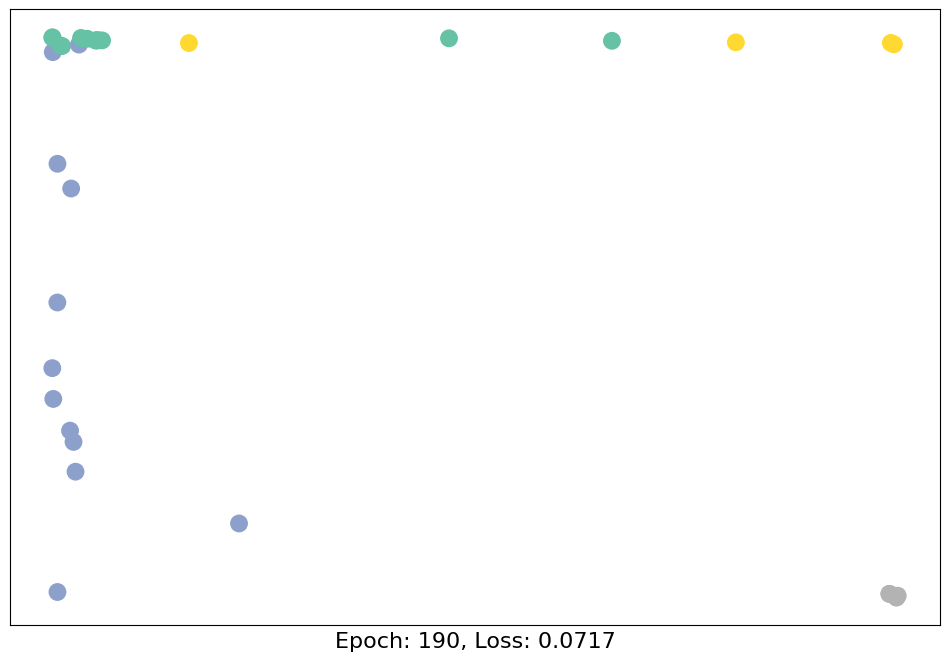

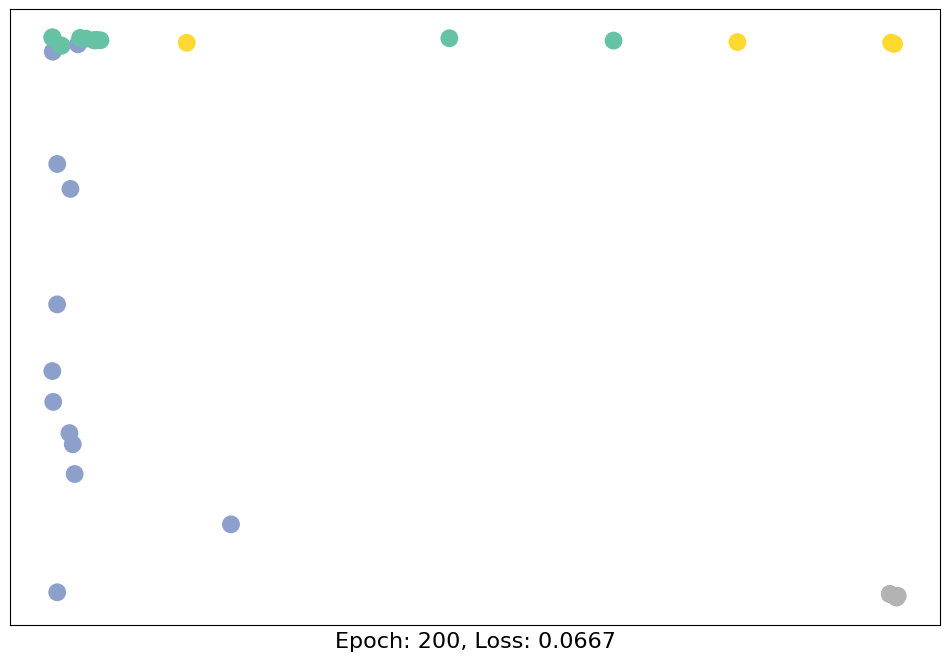

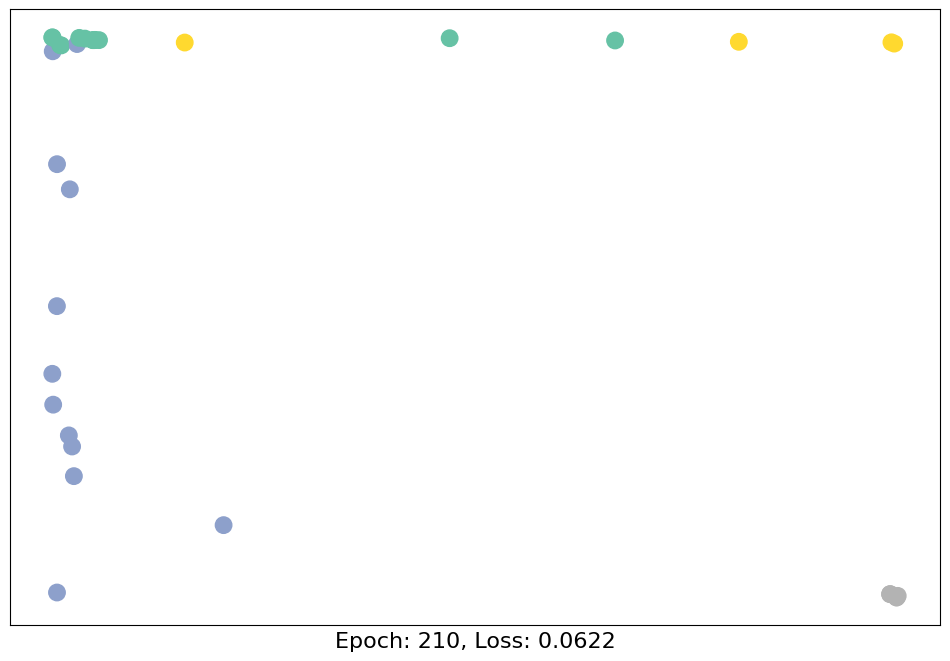

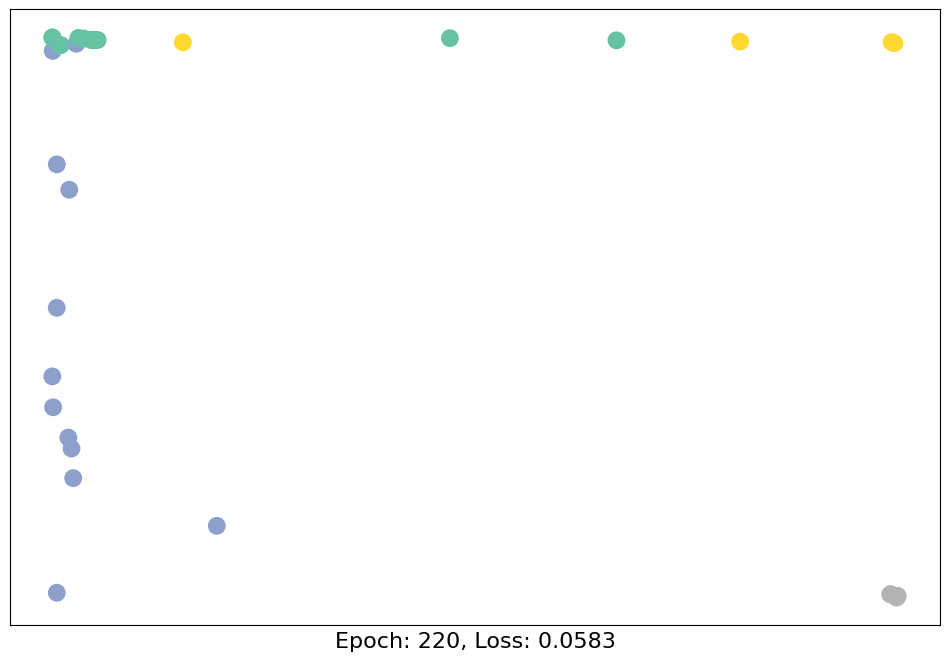

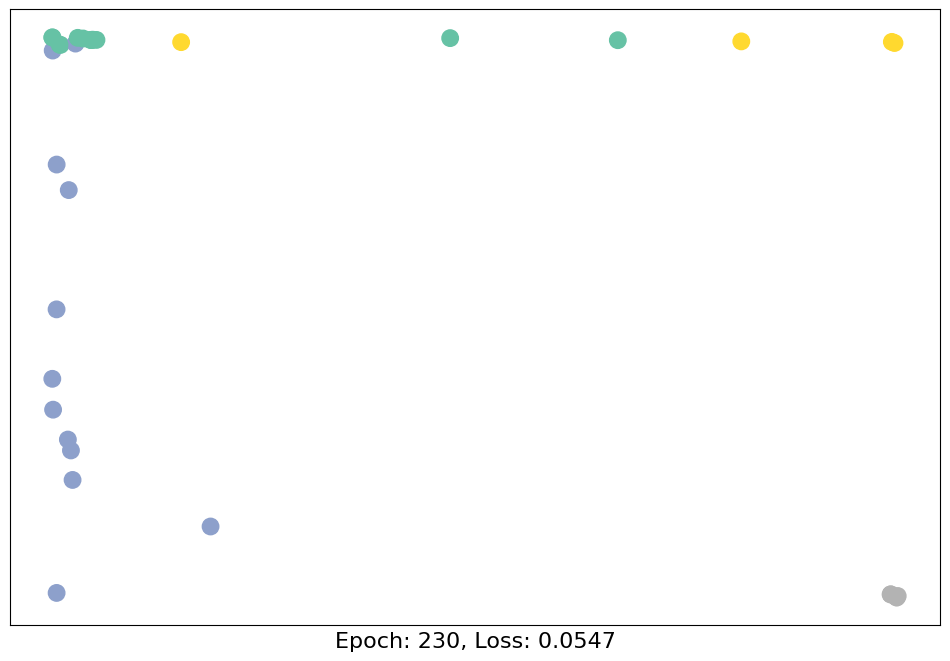

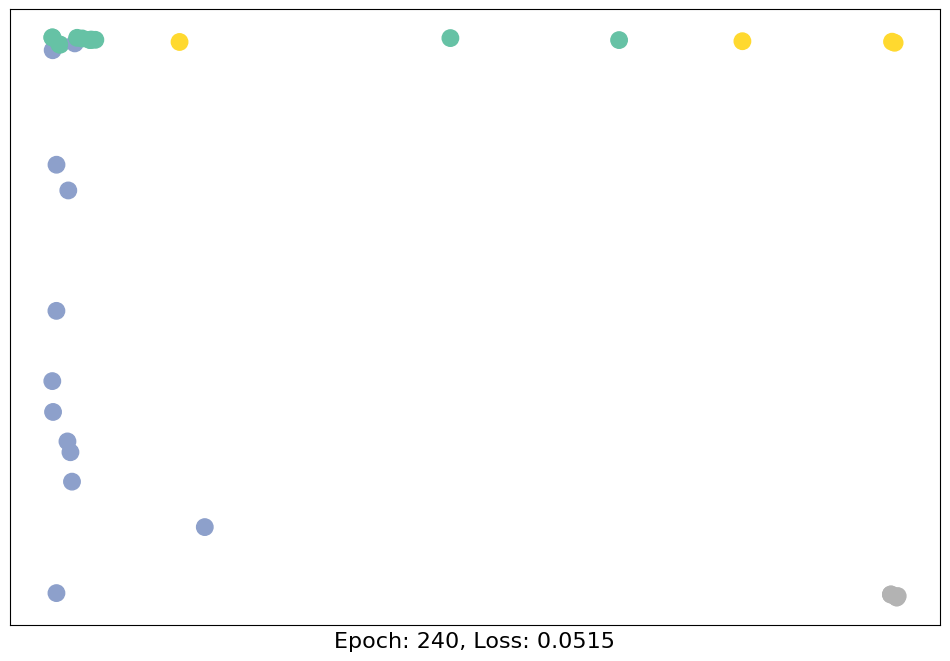

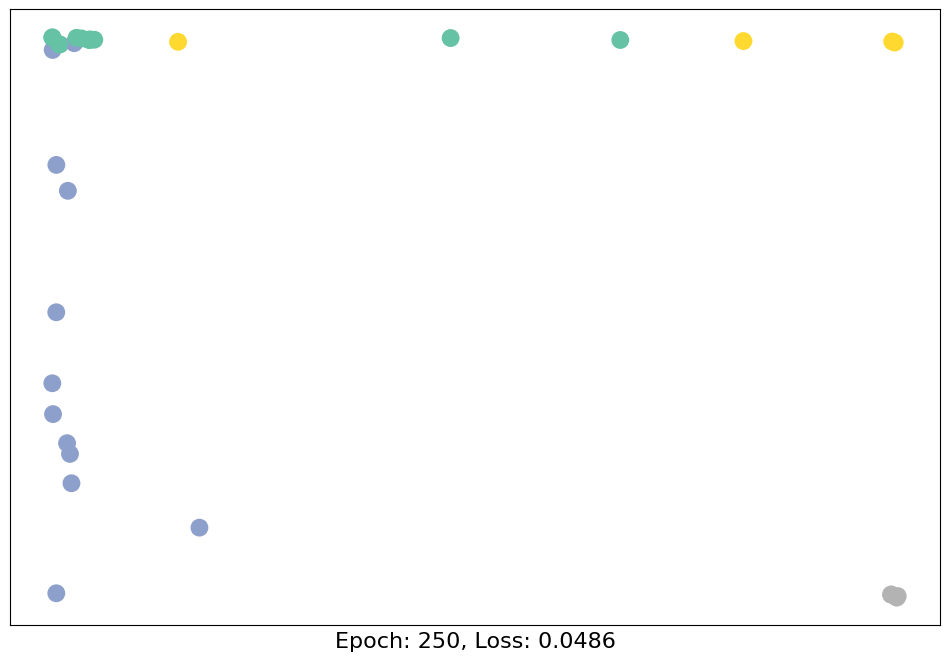

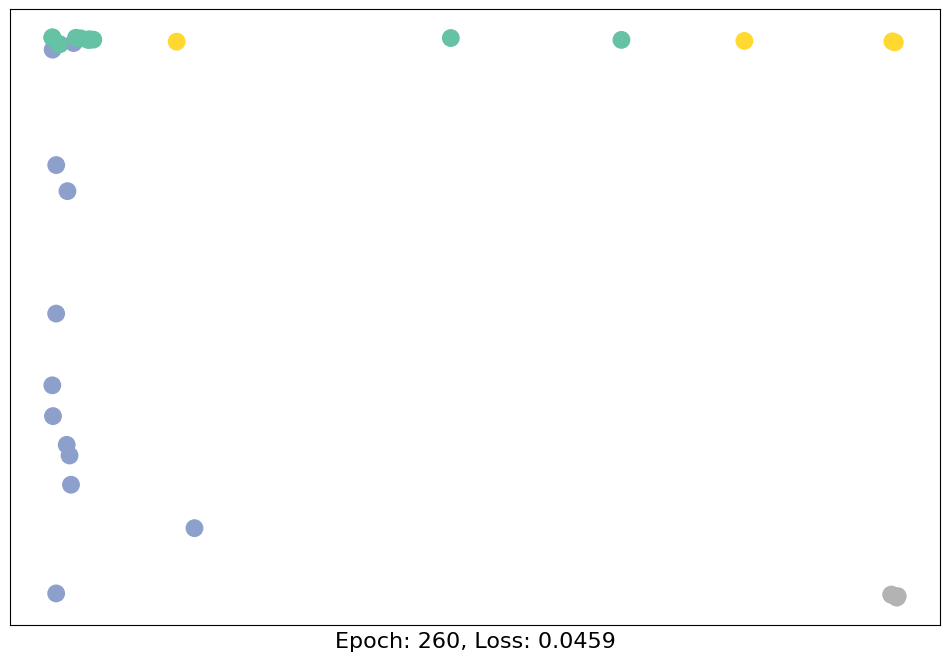

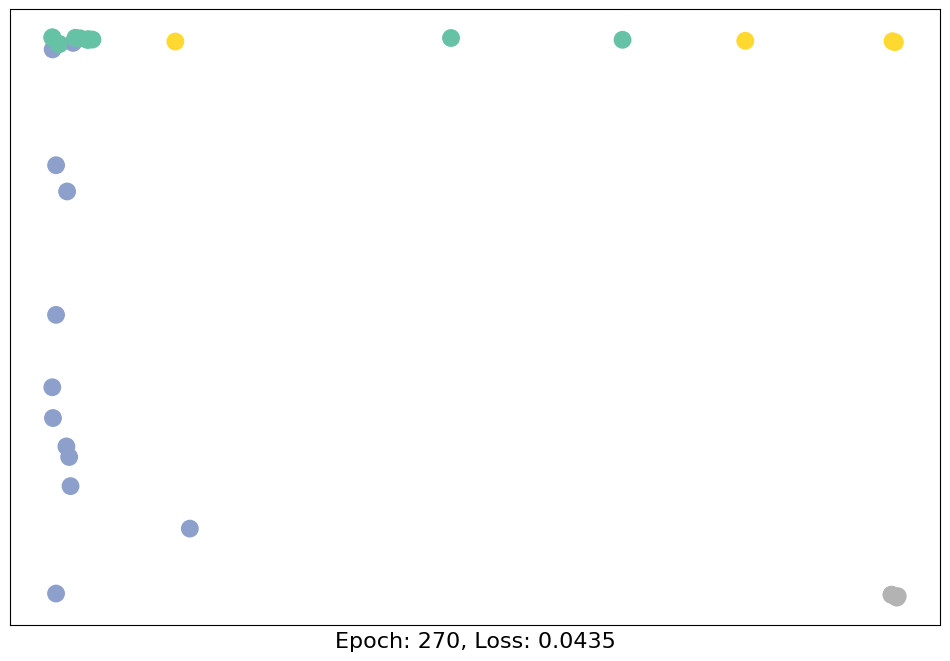

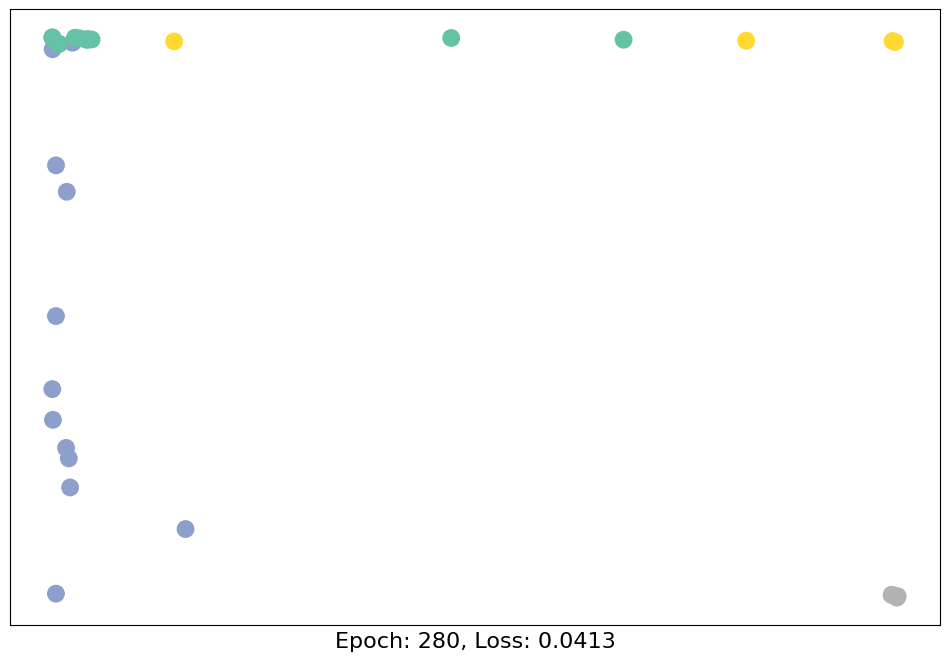

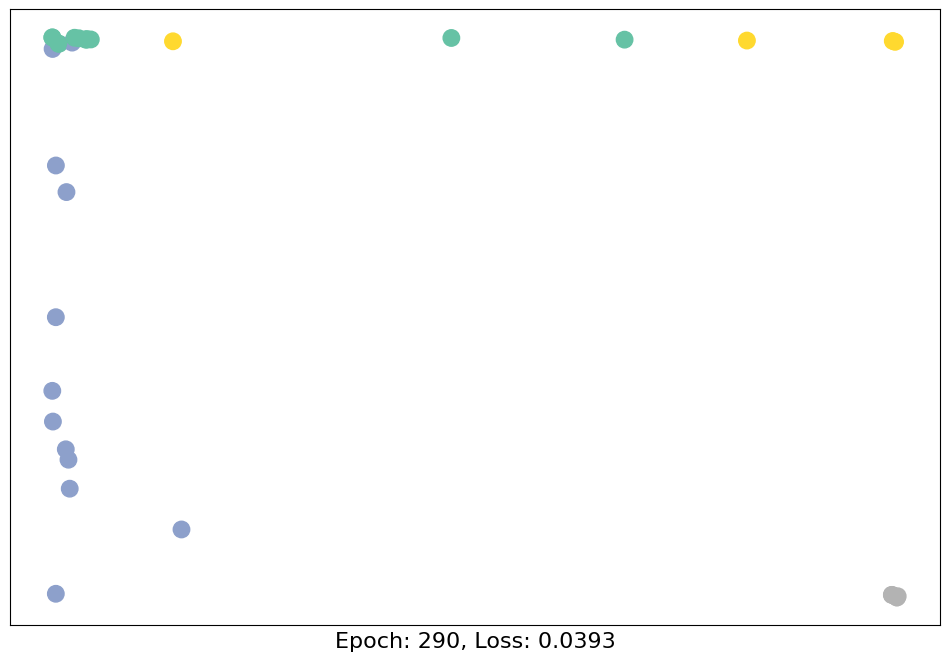

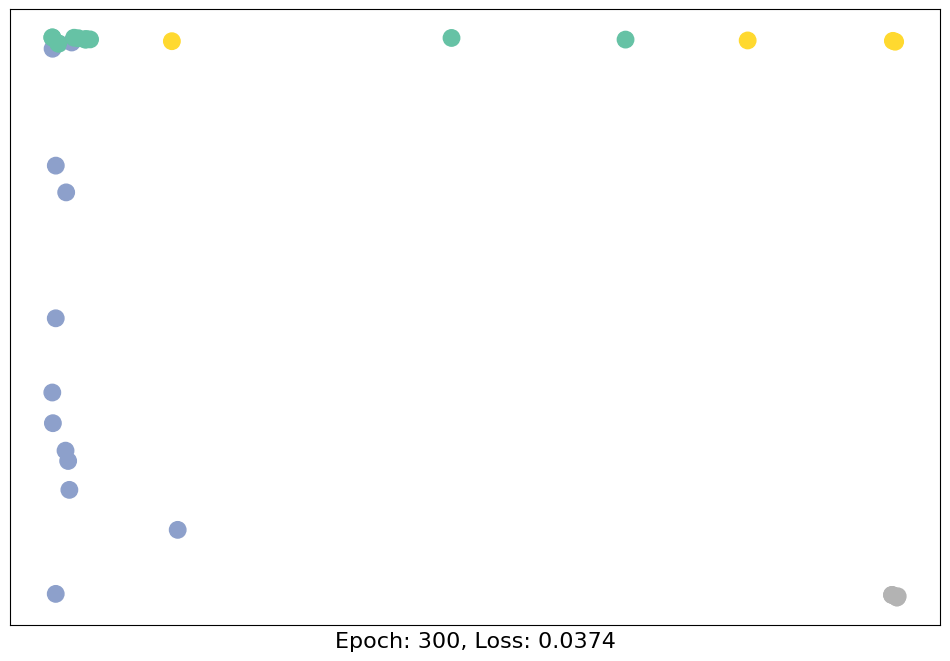

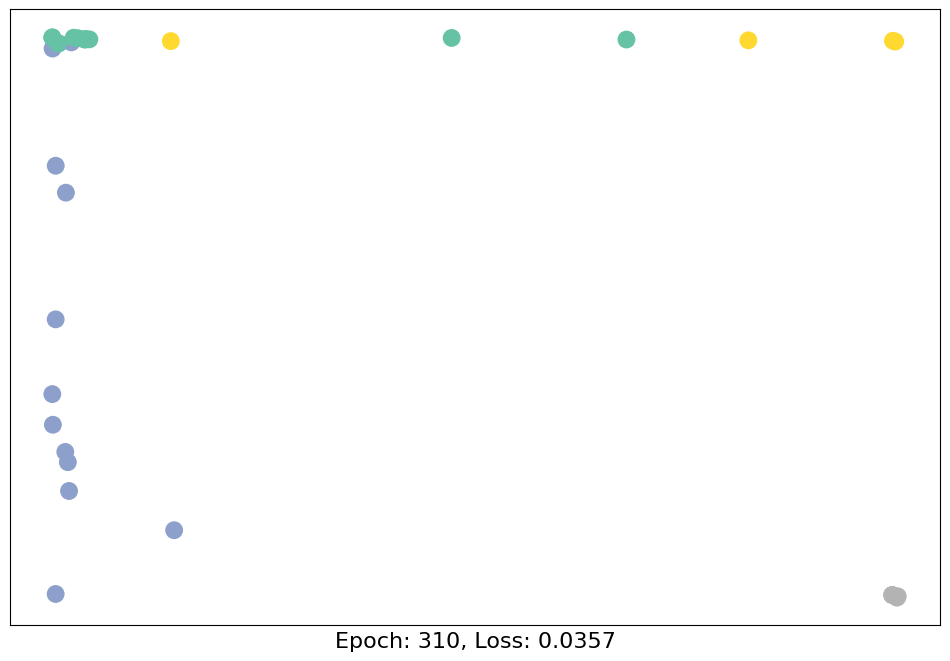

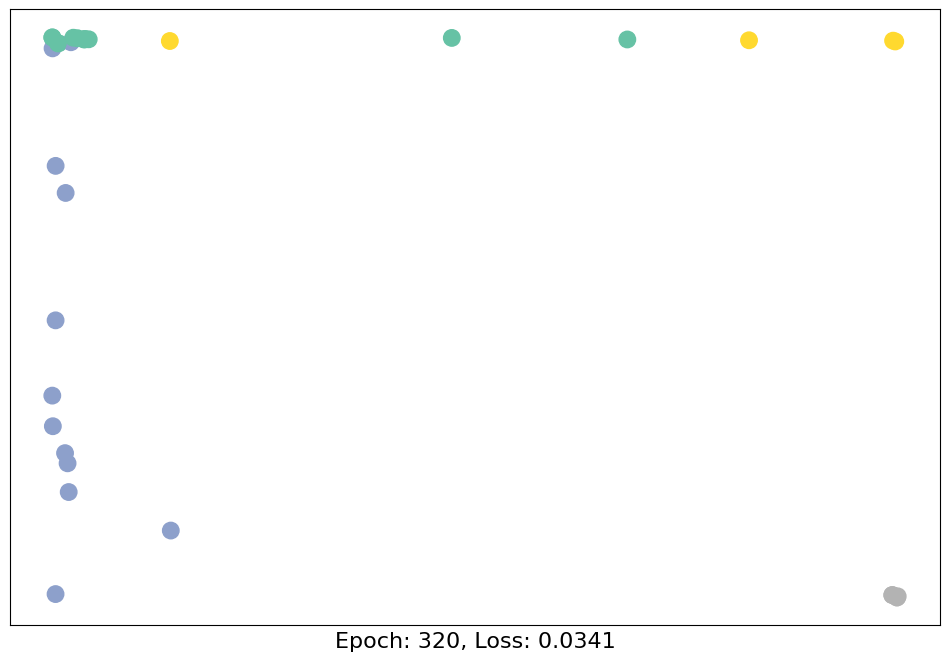

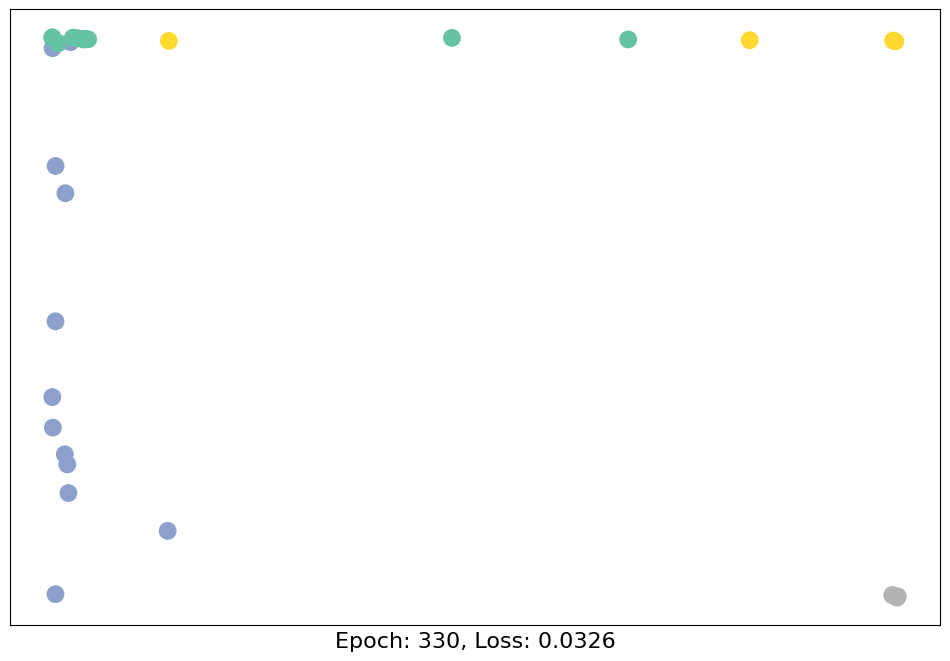

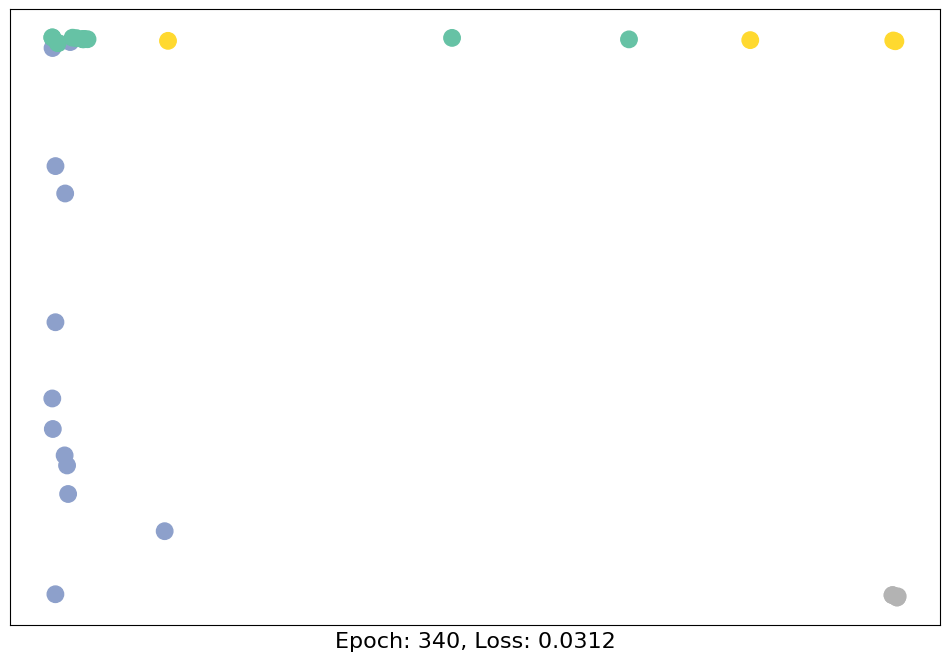

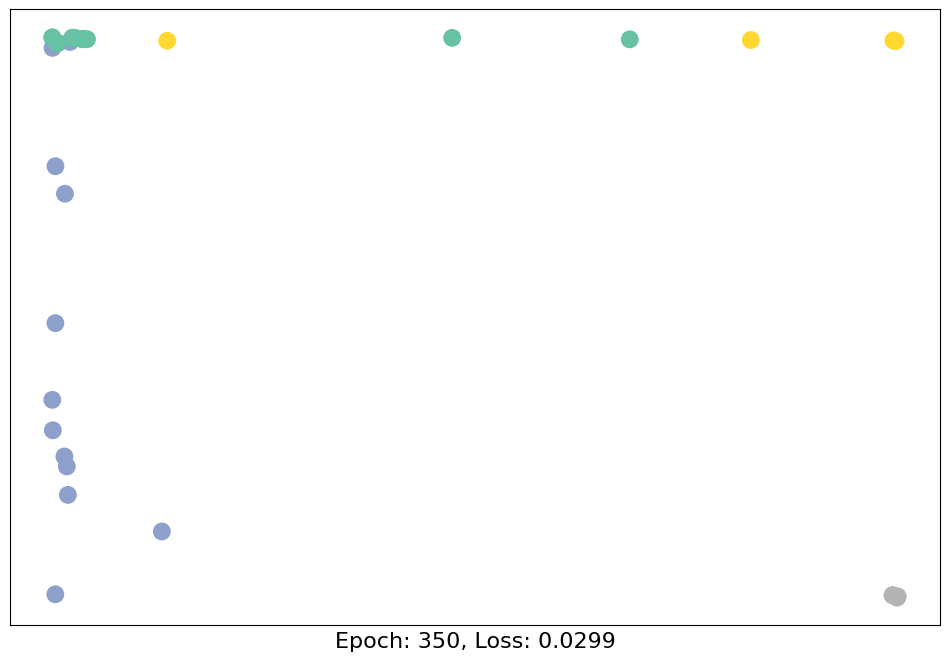

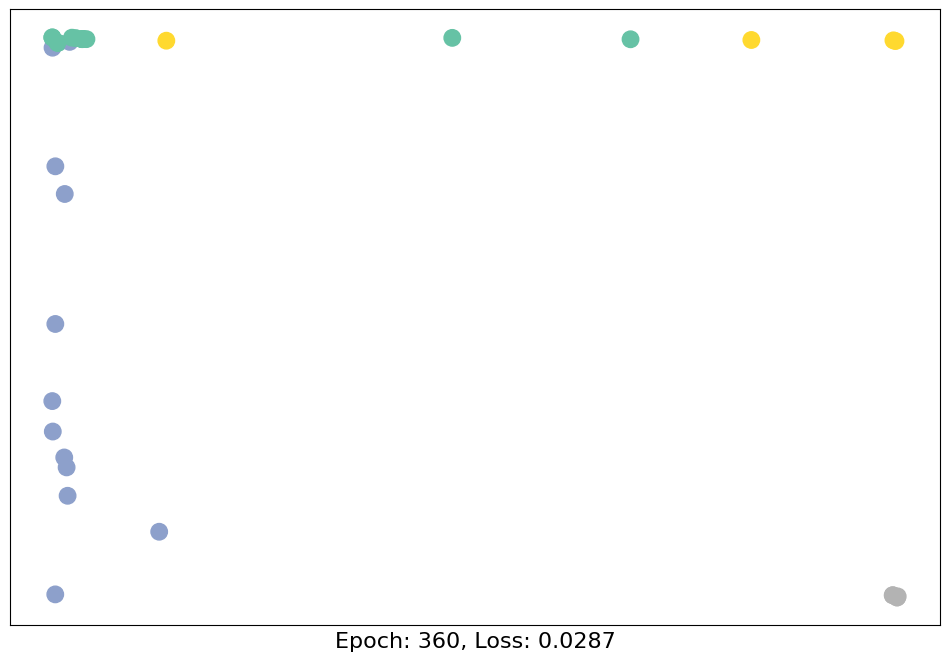

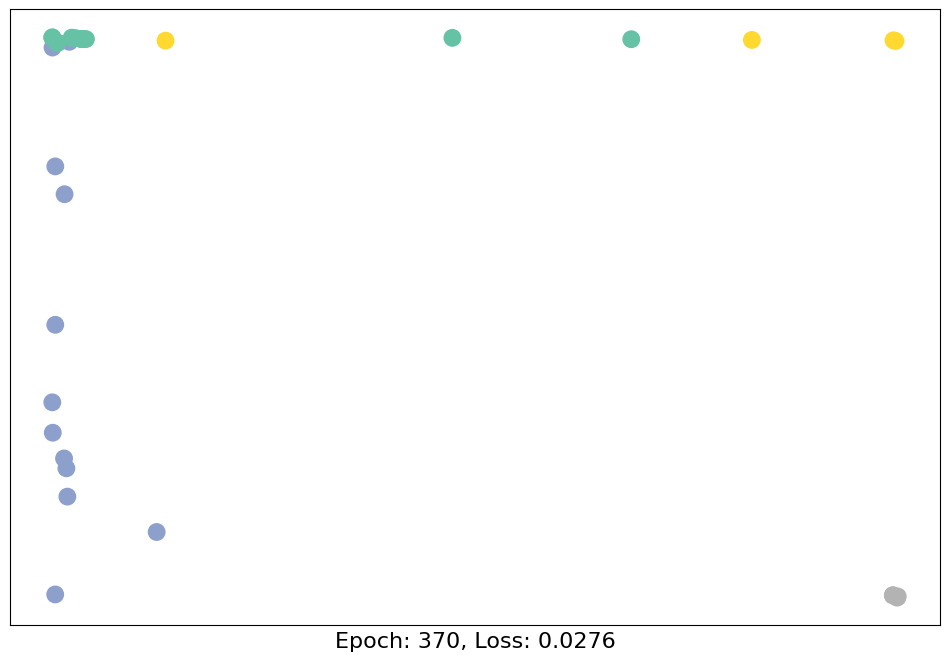

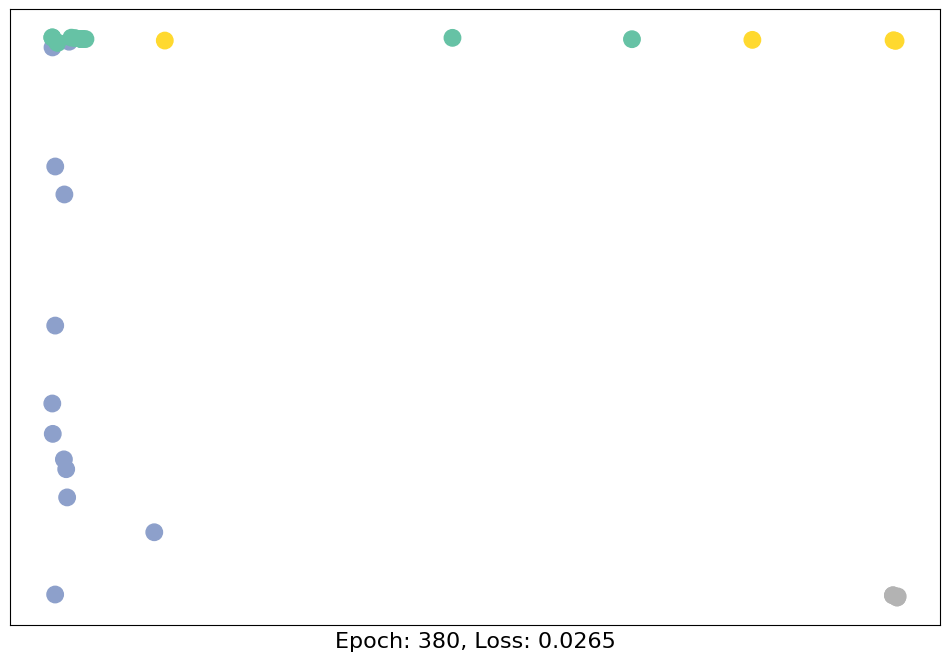

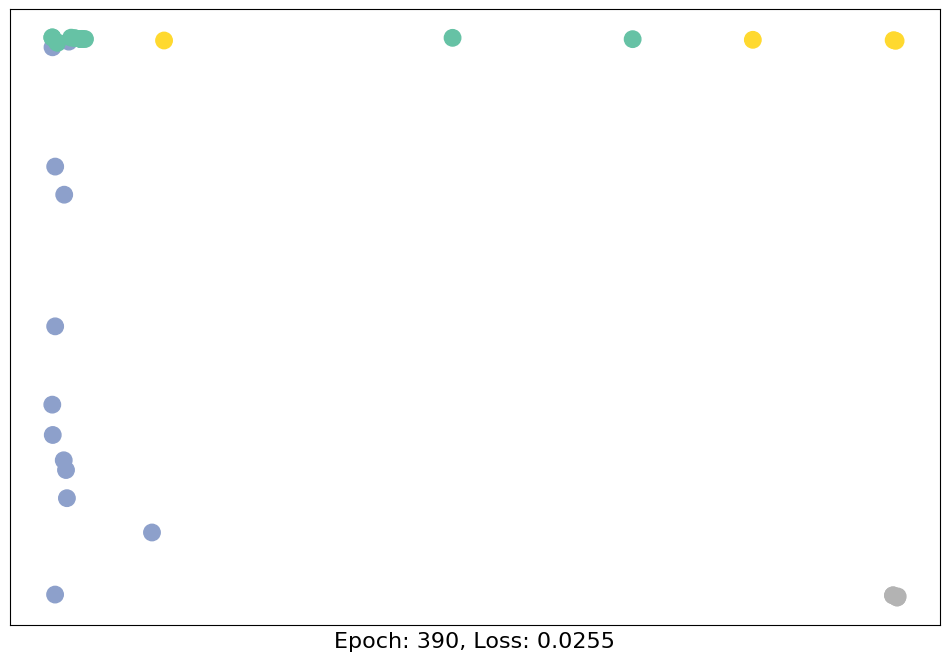

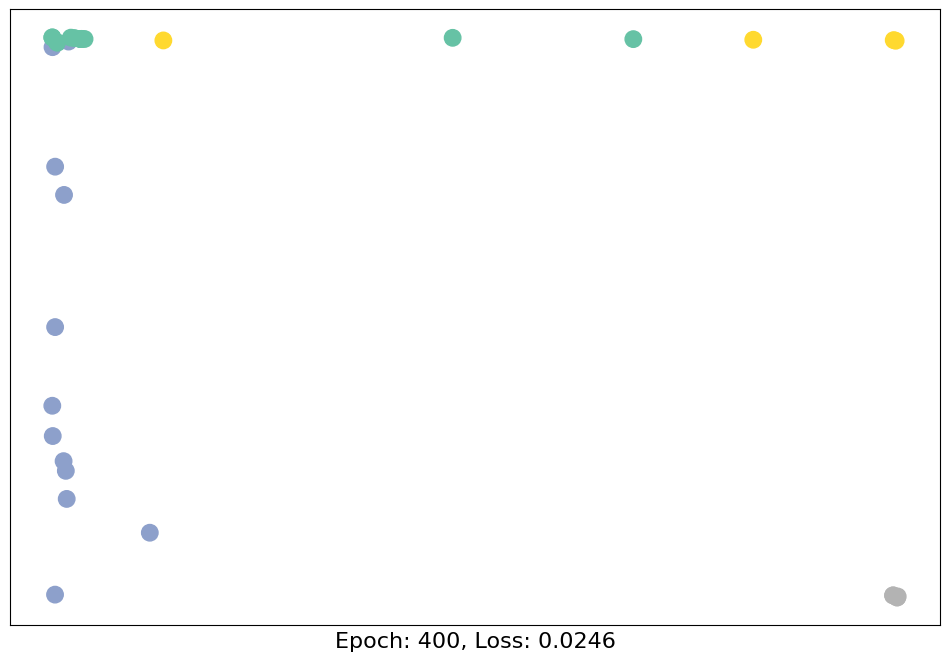

In [23]:
import time
from IPython.display import Javascript # Restrict height of output cell.
display(Javascript('''google.Colab.output.setIframeHeight(0, true, {maxHeight: 430})'''))

model = GCN()
criterion = torch.nn.CrossEntropyLoss() # Loss criterion
optimizer = torch.optim.Adam(model.parameters(), lr=0.01) # Optimizer

final_h = h

def train(data):
  optimizer.zero_grad()# Clearing gradients
  out, h = model(data.x, data.edge_index)
  loss = criterion(out[data.train_mask], data.y[data.train_mask])
  loss.backward() # Deriving gradients
  optimizer.step()
  return loss, h


for epoch in range(401):
  loss, h = train(data)
  if epoch % 10 == 0:
    visualize_embedding(h, color=data.y, epoch=epoch, loss=loss)
    time.sleep(0.3)
    final_h = h


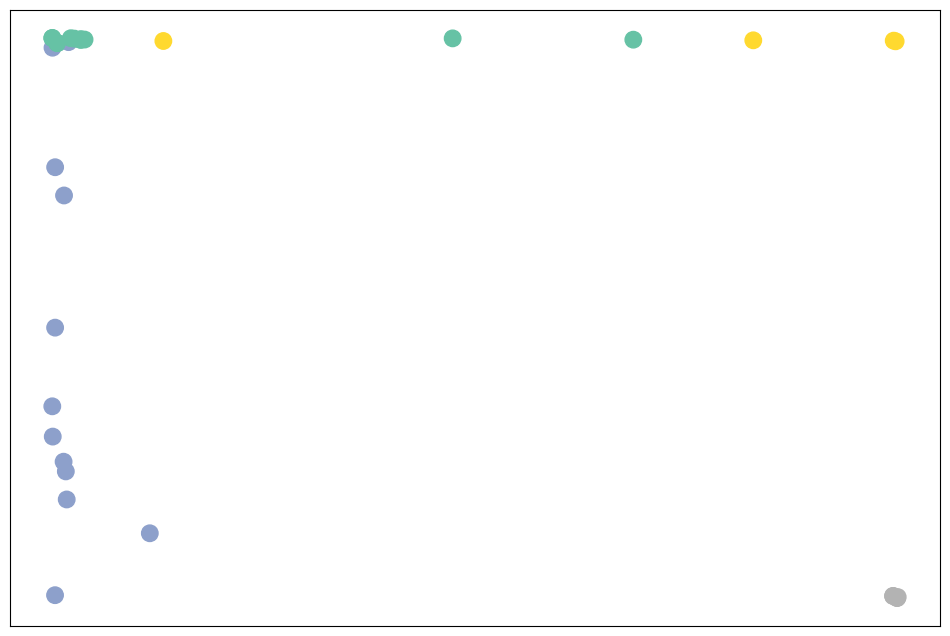

In [26]:
# Last embedding after training
visualize_embedding(h, color=data.y)

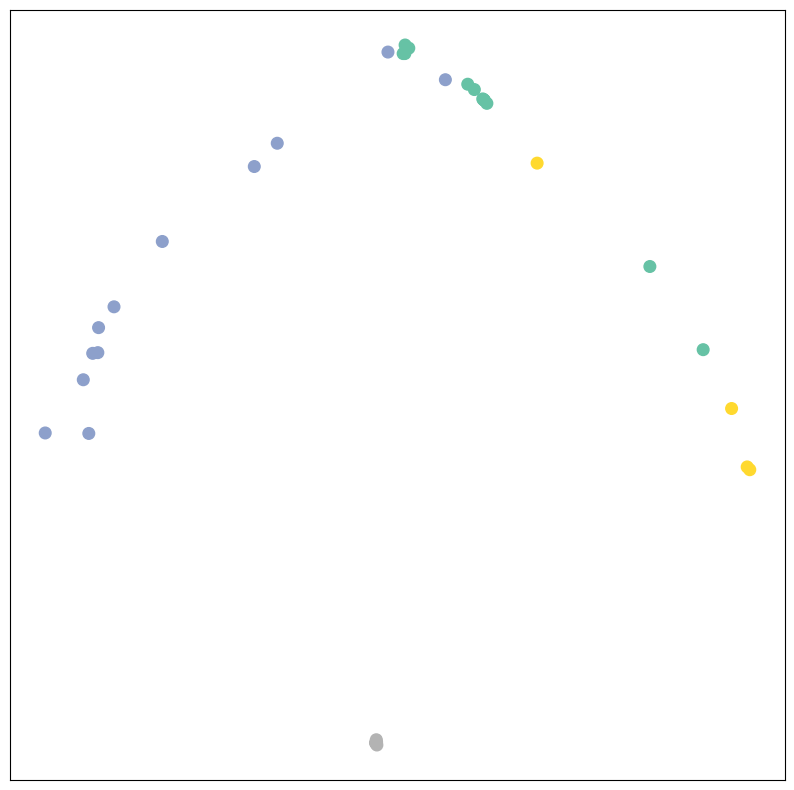

In [33]:
# Visualizing by using TSNE
visualize_tsne(h, color=data.y)

# Result

3 layer GCN model succesfully classify most of the nodes correctly. As, we dont have test mask so we cannot find the accuracy of the graph.

# Model Information

In [37]:
print("Model states:\n", model.state_dict())
print("Model type:\n", model.type)
print("Model shared memory:\n", model.share_memory)
print("Model parameters:\n", model.parameters)
print("Submodule of GCN:\n", model.get_submodule)

Model states:
 OrderedDict({'conv1.bias': tensor([-0.0398,  0.0074,  0.0530,  0.0303]), 'conv1.lin.weight': tensor([[ 0.9893, -0.6488, -0.6693, -0.0615,  0.6027,  1.1585,  0.7938, -0.3729,
         -0.6079, -1.0193,  0.8887, -0.1473,  0.3653, -0.5545, -0.8042, -0.4079,
          1.0150,  0.2699, -0.9723,  0.0088, -0.6479,  0.1900, -0.3529, -0.5920,
          0.4493,  0.3951, -0.5013, -0.0678, -1.1910, -1.0785, -1.0772, -0.2185,
         -0.6120, -0.6529],
        [-1.0868, -1.3011,  0.2456, -0.7954, -0.4431, -0.2655, -0.8488, -1.2820,
          0.0860,  0.4040, -0.9798, -0.7531, -1.0100, -0.8316,  0.4007,  0.5778,
         -0.5675, -1.1067,  0.9949, -1.2402,  0.7423, -1.2624,  0.5717,  0.9572,
          1.2723,  1.3687,  0.7043,  1.0436,  0.9128,  1.2223,  0.2289,  1.3794,
          0.5734,  1.0791],
        [-0.3226,  0.6576,  0.8903,  0.1784, -1.0070, -0.7734, -0.6476, -0.1055,
          0.7784,  0.8775, -1.1782, -0.3493, -0.7400,  0.2780,  0.5610,  0.7195,
         -0.8565, -0.6735,

# Saving The Model

In [42]:
# Only saves learnable parameters.
torch.save(model.state_dict(), "karate-club.h5")

OR

In [41]:
# Saves learnable parameters along with full architecture of the model.
torch.save(model, "karate-club_full.h5")